In [ ]:
import pandas as pd
lead=pd.read_excel('lead_data_20250423120123.xlsx')
lead['name'] = lead['First Name'].astype(str) + ' ' + lead['Family Name'].astype(str)
contract_customer = dict(zip(
    lead['Custom Id'],
    zip(lead['Contract Reference'], lead['name'])
))
# Drop rows where 'Custom Id' is NaN
filtered_lead = lead[lead['Custom Id'].notna()]

# Create the dictionary
contract_customer = dict(zip(
    filtered_lead['Custom Id'],
    zip(filtered_lead['Contract Reference'], filtered_lead['name'])
))

import pandas as pd

# Load and prepare data
payments = pd.read_excel('payments_data_20250423120157.xlsx')
payments['Date'] = pd.to_datetime(payments['Date'])

# Compute std deviation of 'Date' within each wallet group
std_by_wallet = payments.groupby('Payment Wallet Name')['Date'].apply(lambda x: x.std())
std_by_wallet = std_by_wallet.dropna()
irregular = std_by_wallet  # keep all, even low std dev

irregular_df = irregular.reset_index()
irregular_df['Customer Name'] = irregular_df['Payment Wallet Name'].str.extract(r'^(.*?)\s*\(')
irregular_customers=irregular_df['Customer Name'].unique()
# Extract customer name from Payment Wallet Name in payments
payments['Customer Name'] = payments['Payment Wallet Name'].str.extract(r'^(.*?)\s*\(')

# Filter payments for irregular customers
irregular_payments = payments[payments['Customer Name'].isin(irregular_customers)]

# Get the max Payment Wallet Id per irregular customer
max_wallet_ids = irregular_payments.groupby('Customer Name')['Payment Wallet Id'].max().reset_index()
reconciled_payments=pd.read_excel('reconciled_payment_data_20250423120155.xlsx')
wallet_contract=dict(zip(reconciled_payments['Destination Contract Reference'],reconciled_payments['Payment Wallet Id']))
# Reverse the dictionary: Payment Wallet Id → Contract Reference
from collections import defaultdict

# Create a reverse lookup (handle 1-to-many if needed)
wallet_to_contract = defaultdict(list)
for contract, wallet in wallet_contract.items():
    wallet_to_contract[wallet].append(contract)

# Now map from Payment Wallet Id to first matching contract (or all if you prefer)
max_wallet_ids['Contract Reference'] = max_wallet_ids['Payment Wallet Id'].map(
    lambda x: wallet_to_contract.get(x, [None])[0]
)
max_wallet_ids
contract_dict=pd.read_excel('repayment_data_20250423120137.xlsx')[['Contract Id','Contract Reference']]
contract_dict=dict(zip(contract_dict['Contract Reference'],contract_dict['Contract Id']))
max_wallet_ids['Contract Id'] = (
    max_wallet_ids['Contract Reference']
    .map(contract_dict)
    .dropna()
    .astype(int)
)
client_data=pd.read_excel('client_data_20250423120102.xlsx')
client_data['Customer Name']=client_data['First Name'].astype(str) + ' ' + client_data['Family Name'].astype(str)
client_id_name=dict(zip(client_data['Customer Name'],client_data['Id']))
max_wallet_ids['Client Id'] = max_wallet_ids['Customer Name'].map(client_id_name)
max_wallet_ids=max_wallet_ids.merge(client_data,on='Customer Name', how='left')
max_wallet_ids = max_wallet_ids[
    ['Customer Name', 'Payment Wallet Id', 'Contract Reference',
     'Has Active Contracts', 'Has Completed Contracts', 'Has Defaulted Contracts', 'Has Late Contracts',
     'L0 Entity Name', 'L1 Entity Name', 'L2 Entity Name', 'L3 Entity Name', 'L4 Entity Name','Contract Id']
]
max_wallet_ids.dropna()
stock_data=pd.read_excel('stock_data_20250423120233.xlsx')
stock_data=stock_data[stock_data['With Client Id'].notna()]
stock_data['Customer Id'] = stock_data['With Client Id'].astype('int64')
stock_cust_id = dict(zip(stock_data['Customer Id'], stock_data['Type']))
max_wallet_ids=max_wallet_ids[max_wallet_ids['Contract Id'].notna()]
max_wallet_ids['Contract Id'] =max_wallet_ids['Contract Id'].astype('int64')
# Ensure 'Contract Id' is int64 in both dataframes
stock_data['Contract Id'] = stock_data['Contract Id'].astype('int64', errors='ignore')
df = max_wallet_ids.copy()

df['Contract Id'] = df['Contract Id'].astype('int64', errors='ignore')

# Select only needed columns from stock_data
stock_subtype = stock_data[['Contract Id', 'Product Sub Type Id']].dropna()

# Final assignment of cleaned base table
df['Contract Id'] = df['Contract Id'].astype('int64', errors='ignore')
df['Type'] = df['Contract Id'].map(stock_cust_id)

# Map Type from stock_data

# Add Product Sub Type Id from stock_data
stock_data['Contract Id'] = stock_data['Contract Id'].astype('int64', errors='ignore')
stock_subtype = stock_data[['Contract Id', 'Product Sub Type Id']].dropna()
df = df.merge(stock_subtype, on='Contract Id', how='left')

# Fill NaNs in boolean columns with False
bool_cols = ['Has Active Contracts', 'Has Completed Contracts', 'Has Defaulted Contracts', 'Has Late Contracts']
df[bool_cols] = df[bool_cols].fillna(False)

# Identify possible connectivity issues
df['Possible Connectivity Issue'] = (
    (~df['Has Active Contracts']) &
    (~df['Has Completed Contracts']) &
    (~df['Has Defaulted Contracts']) &
    (~df['Has Late Contracts'])
)
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report, confusion_matrix
import pandas as pd
df_encoded = df.copy()

# Convert all columns to category if appropriate
for col in df_encoded.columns:
    df_encoded[col] = df_encoded[col].astype('category')
df=df_encoded.copy()
for col in df.columns:
    mode = df[col].mode(dropna=True)
    if not mode.empty:
        df[col] = df[col].fillna(mode[0])

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.preprocessing import OneHotEncoder
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from scipy.sparse import hstack
import pandas as pd

df

C:\Users\Linh\AppData\Local\Temp\ipykernel_35532\3184238503.py:101: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df[bool_cols] = df[bool_cols].fillna(False)


,Customer Name,Payment Wallet Id,Contract Reference,Has Active Contracts,Has Completed Contracts,Has Defaulted Contracts,Has Late Contracts,L0 Entity Name,L1 Entity Name,L2 Entity Name,L3 Entity Name,L4 Entity Name,Contract Id,Type,Product Sub Type Id,Possible Connectivity Issue
0,Abel Eduardo Munoz Cantillo,310,C3170016,True,False,False,False,Kainnamana,Manaure,Headquarters,Default Zone,Default Region,261,SKG,1.0,False
1,Abraham Epinayu Epinayu,737,C7450018,True,False,False,False,Uyaraica,Manaure,Headquarters,Default Zone,Default Region,666,SKG,1.0,False
2,Achi Uriana Epiayu,115,C1210012,False,False,True,False,Jonchon,Default Cluster,Headquarters,Default Zone,Default Region,99,SKG,1.0,False
3,Adalcinda Segunda Martinez Epieyu,317,C3240017,True,False,False,False,Kainnamana,Manaure,Headquarters,Default Zone,Default Region,268,SKG,1.0,False
4,Adelica Rosa Epieyu Martinez,524,C5320015,False,False,True,False,Maniature,Manaure,Headquarters,Default Zone,Default Region,458,SKG,1.0,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
728,prueba 4,41,C470013,True,False,False,False,Bukuamake,Default Cluster,Headquarters,Default Zone,Default Region,29,SKG,1.0,False
729,prueba 4987309,814,C8240012,False,False,False,False,Kainnamana,Manaure,Headquarters,Default Zone,Default Region,745,SKG,1.0,True
730,rita epieyu,359,C3660016,True,False,False,False,Kayetamana,Default Cluster,Headquarters,Default Zone,Default Region,308,SKG,1.0,False
731,yeimis Epiayu Epinayu,194,C2010015,True,False,False,False,Kainnamana,Manaure,Headquarters,Default Zone,Default Region,149,SKG,1.0,False


Confusion Matrix:
 [[103  25]
 [  0  19]]

Classification Report:
               precision    recall  f1-score   support

         0.0       1.00      0.80      0.89       128
         1.0       0.43      1.00      0.60        19

    accuracy                           0.83       147
   macro avg       0.72      0.90      0.75       147
weighted avg       0.93      0.83      0.85       147


Accuracy: 0.8299


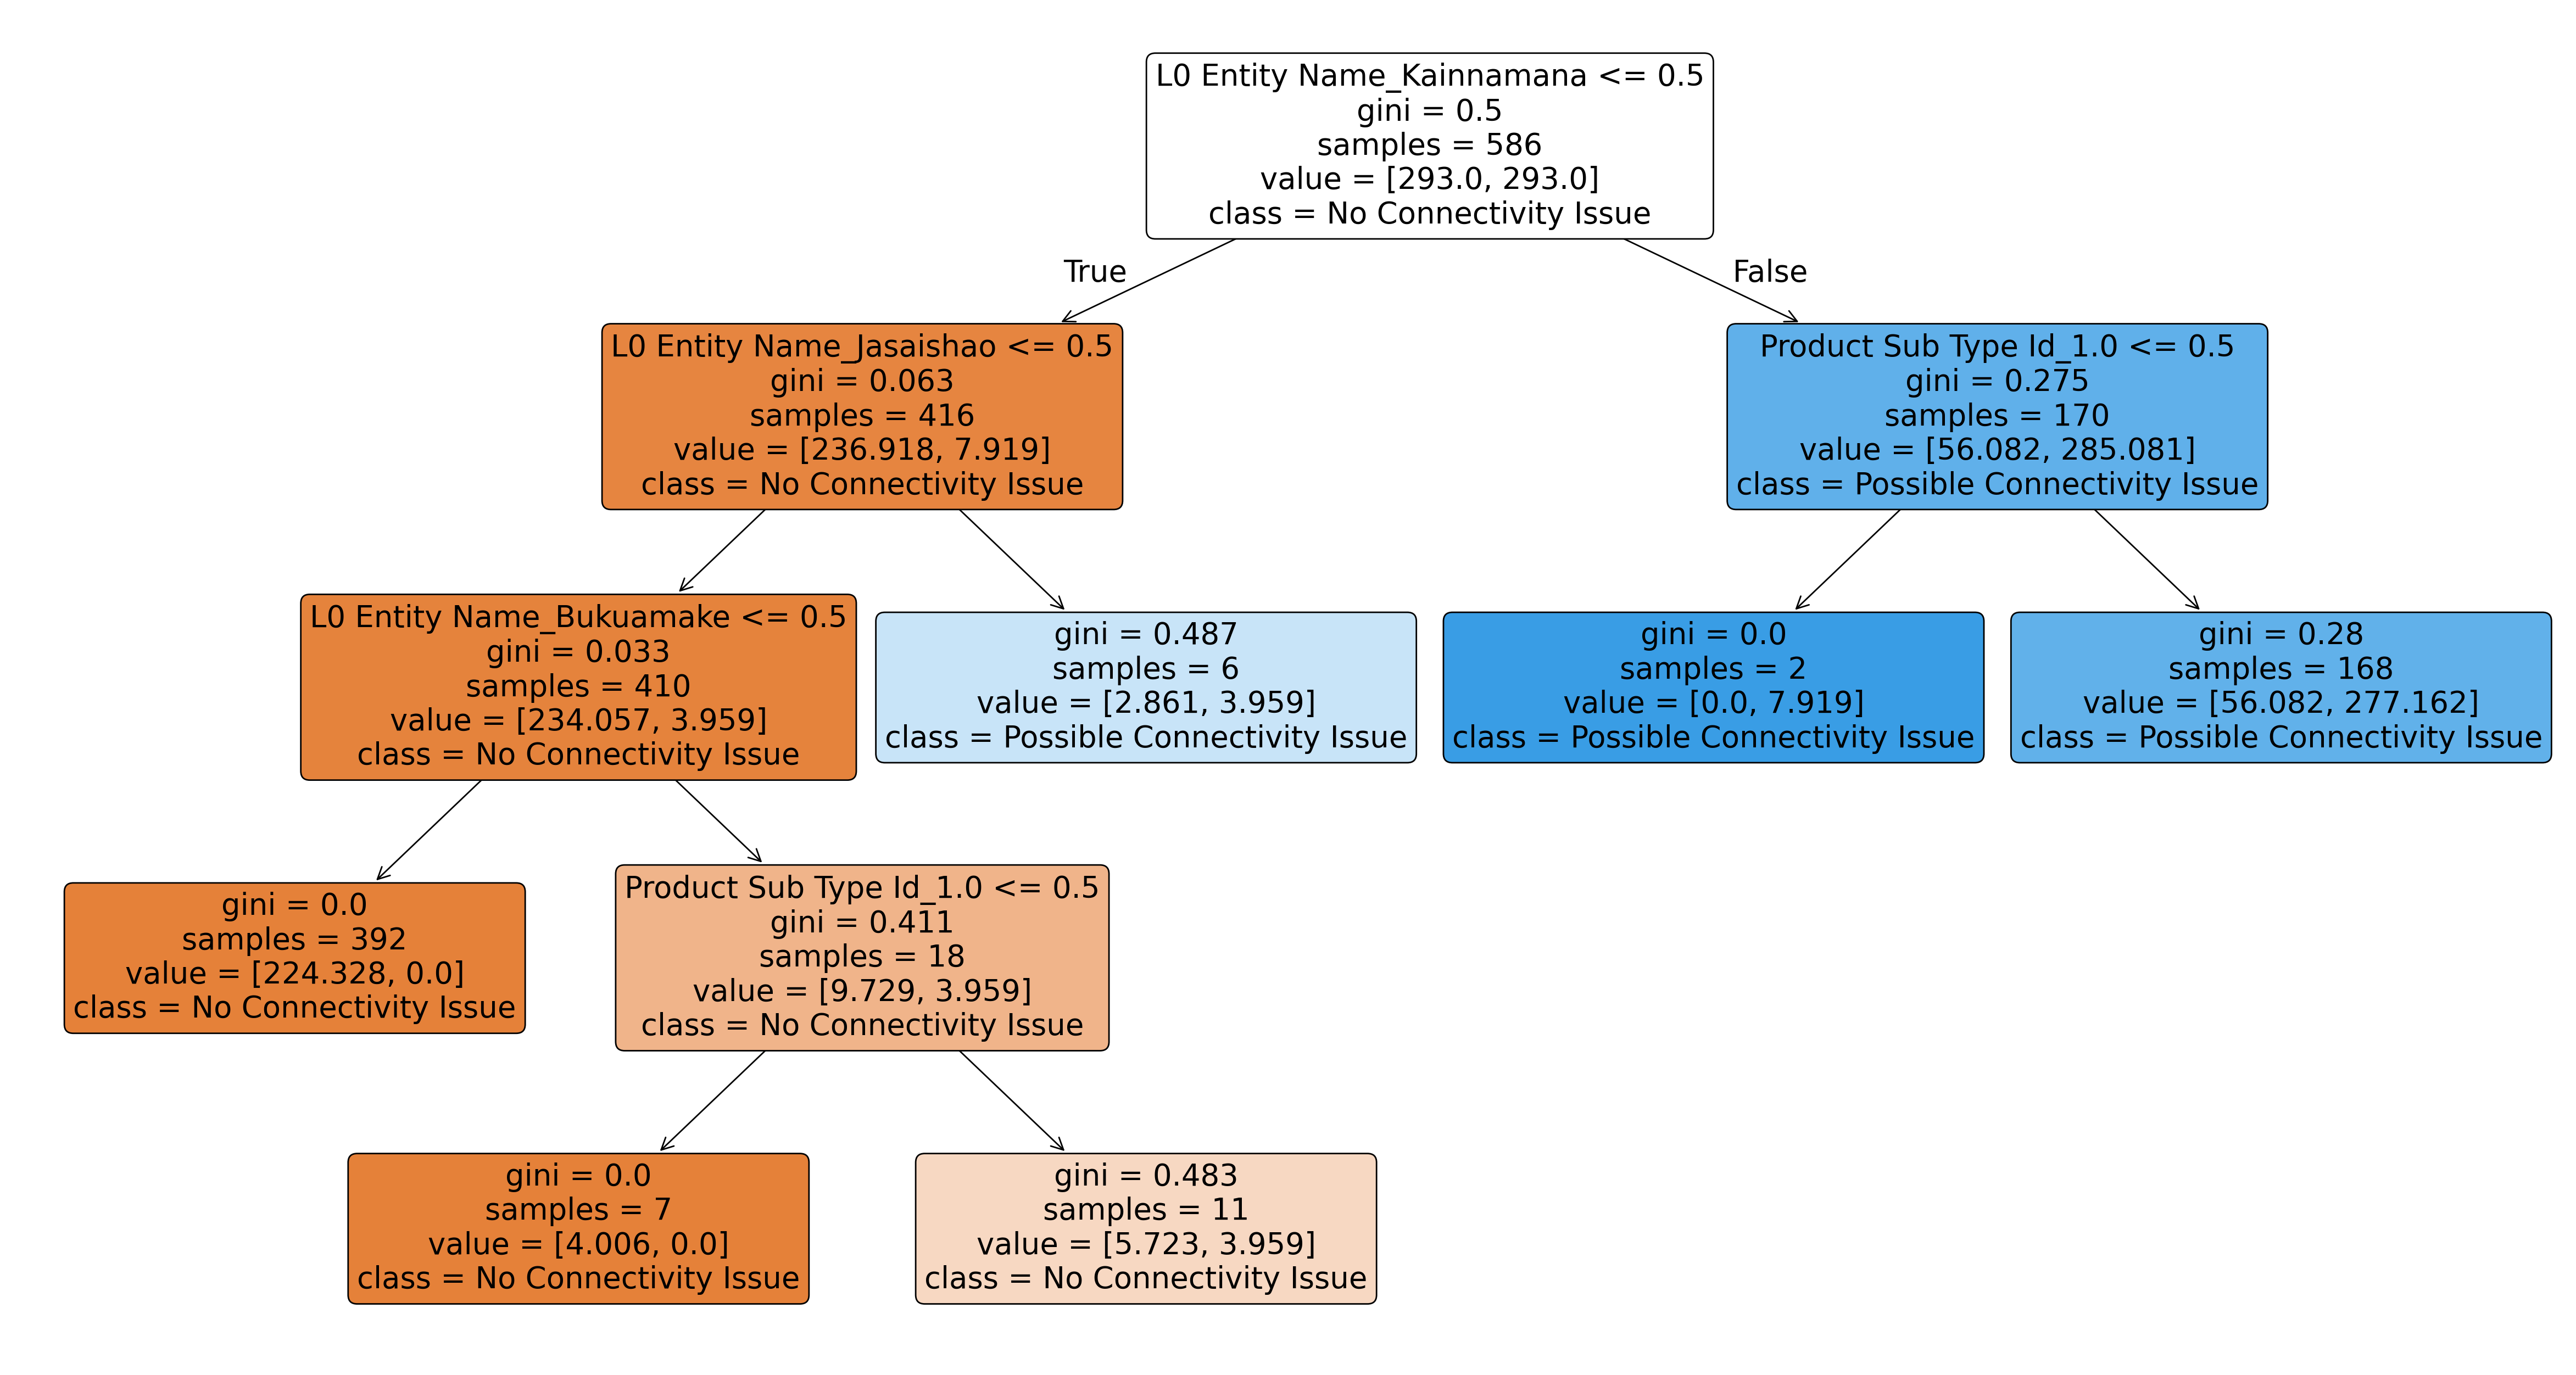

In [ ]:
# Step 1: Define features and target
X = df[[ 'L0 Entity Name','Product Sub Type Id']]
y = df['Possible Connectivity Issue']

# Step 2: Split BEFORE encoding
X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Step 3: Separate categorical and numeric columns
cat_cols =['L0 Entity Name','Product Sub Type Id']
num_cols = []


# Step 4: One-hot encode categorical columns (sparse)
ohe = OneHotEncoder(handle_unknown='ignore', sparse_output=True)
X_train_cat = ohe.fit_transform(X_train_raw[cat_cols])
X_test_cat = ohe.transform(X_test_raw[cat_cols])

# Step 5: Combine categorical + numeric (as sparse matrices)
from scipy.sparse import csr_matrix

X_train_num = csr_matrix(X_train_raw[num_cols].values)
X_test_num = csr_matrix(X_test_raw[num_cols].values)

X_train_final = hstack([X_train_cat, X_train_num])
X_test_final = hstack([X_test_cat, X_test_num])

# Step 6: Train Decision Tree
clf = DecisionTreeClassifier(class_weight='balanced', max_depth=15, random_state=42)
clf.fit(X_train_final, y_train)

# Step 7: Predict and evaluate
y_pred = clf.predict(X_test_final)
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))
print(f"\nAccuracy: {accuracy_score(y_test, y_pred):.4f}")




# Define feature and class names
feature_names = ohe.get_feature_names_out(cat_cols).tolist()
class_names = ['No Connectivity Issue', 'Possible Connectivity Issue']

# Plot the decision tree
import matplotlib.pyplot as plt
plt.figure(figsize=(30, 16), dpi=200)
tree.plot_tree(
    clf,
    feature_names=feature_names,
    class_names=class_names,
    filled=True,
    max_depth=None,
    rounded=True
)
plt.show()
